# Knee Exo — encoder replay vs Vicon IK oracle (no-LPF pipeline)

GPIO-synced offline TCN replay for all `*_knee_*_exo_on` telemetry trials, using the **no-LPF** methodology from `compare_ab01_knee_rd_no_lpf_test` (finetuned checkpoint `runs/0707_knee_finetune_balanced_lg_ra_rd/best_model.pt`).

- **Sync**: GPIO falling-edge alignment
- **Inputs**: raw, **no input LPF** (Vicon: B-spline velocity; encoder: logged `model_in_knee_vel_raw`)
- **Output**: raw TCN → zero-phase 6 Hz LPF
- **GT**: Vicon ID/mass − `cmd_R`/mass, zero-phase 6 Hz LPF, per-trial encoder–IK xcorr ID shift
- **Vicon IK oracle** and **encoder replay** vs same GT (10 s trim each end)
- **Exclusions**: set `EXCLUDE_SUBJECTS` / `EXCLUDE_TRIALS` in config to drop faulty data from batch, replay, and paper


In [8]:
import io
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.signal import butter, sosfilt, sosfiltfilt

PROJECT_ROOT = Path('/home/metamobility3/Jinwoo/os_kinetics').resolve()
PROCESSED_ROOT = Path('/media/metamobility3/Samsung_T52/Results/processed')
TELEMETRY_ROOT = PROJECT_ROOT

EXO_KIND = 'knee-exo'
JOINT = 'knee_angle_r'
JOINT_LABEL = 'Knee R'
MOMENT_COL = 'knee_angle_r_moment'
MOCAP_FS_HZ = 1000.0
LPF_CUTOFF_HZ, LPF_ORDER = 6.0, 4
GT_LPF_MODE = 'zero_phase'
MODEL_LPF_MODE = 'zero_phase'
# Fixed global alignment of the replay OUTPUT to GT (samples; negative => delay output).
# Corrects a systematic ~60 ms lead of the model moment over the GT moment that the
# encoder-IK angle xcorr ID shift does not capture (Section 3b sweep: Vicon best -7, encoder -5).
MODEL_OUT_ALIGN_LAG_SAMPLES = -6
TELEMETRY_PATTERN = '*_knee_*_exo_on.npz'
PAPER_SUBDIR = 'knee_exo'

SUBJECT_TOKEN_TO_DIR = {
    'ab01_jinwoo': 'AB01_Jinwoo', 'ab02_oscar': 'AB02_Oscar', 'ab03_ilseung': 'AB03_Ilseung',
    'ab04_changseob': 'AB04_Changseob', 'ab05_maria': 'AB05_Maria', 'ab06_jimin': 'AB06_Jimin',
    'ab07_amy': 'AB07_Amy', 'ab08_seokhyun': 'AB08_Seokhyun',
}
# Per-subject processed-dir overrides (absolute). AB01 uses the freshly reprocessed
# `ab01_jinwoo_knee` dir — the same data compare_ab01_knee_rd_no_lpf_test reads.
# (The stale processed/AB01_Jinwoo IK is uncorrelated with the encoder → bad GT xcorr.)
SUBJECT_DIR_OVERRIDE = {
    'ab01_jinwoo': Path('/media/metamobility3/Samsung_T52/Results/ab01_jinwoo_knee'),
}
SUBJECT_MASS_KG = {
    'ab01_jinwoo': 88.0, 'ab02_oscar': 71.1, 'ab03_ilseung': 84.4, 'ab04_changseob': 74.0,
    'ab05_maria': 55.0, 'ab06_jimin': 82.6, 'ab07_amy': 51.3, 'ab08_seokhyun': 71.9,
}

CACHE_DIR = PROJECT_ROOT / 'analysis' / 'cache'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_PATH = CACHE_DIR / 'compare_processed_knee_exo_id.npz'
REPLAY_METRICS_CSV = CACHE_DIR / 'compare_processed_knee_exo_id_replay_metrics.csv'

LOAD_FROM_CACHE = False
SAVE_TO_CACHE = True

# Post-sync trim applied to metrics and plots (set ends to 0.0 to disable).
TRIM_START_SEC = 10.0
TRIM_END_SEC = 10.0

# Faulty subjects/trials — excluded from batch load, replay, metrics, and paper.
# Subject names must match SUBJECT_TOKEN_TO_DIR values (e.g. 'AB02_Oscar').
# EXCLUDE_SUBJECTS = {'AB02_Oscar', 'AB05_Maria', 'AB07_Amy', 'AB08_Seokhyun'}  # set() to include all subjects
EXCLUDE_SUBJECTS = {'AB02_Oscar'}
EXCLUDE_TRIALS = {'AB05_Maria::RD_0p8mps'}

# Per-trial GT corrections (applied after ID/cmd GT construction + LPF).
GT_OFFSET_NMPKG_BY_STEM = {
    'ab08_seokhyun_knee_0p8mps_ra_exo_on': 0.2,
    'ab08_seokhyun_knee_0p8mps_rd_exo_on': 0.3,
}
GT_LAG_SAMPLES_BY_STEM = {
    'ab07_amy_knee_0p8mps_ra_exo_on': 8,  # GT leads model outputs ~80 ms
}

print(f'Exo: {EXO_KIND} | joint: {JOINT_LABEL}')
print(f'Processed root: {PROCESSED_ROOT}')
print(f'Cache: {CACHE_PATH}')
print(f'LOAD_FROM_CACHE={LOAD_FROM_CACHE} | SAVE_TO_CACHE={SAVE_TO_CACHE}')
print(f'EXCLUDE_SUBJECTS={sorted(EXCLUDE_SUBJECTS) if EXCLUDE_SUBJECTS else []}')
print(f'EXCLUDE_TRIALS={sorted(EXCLUDE_TRIALS) if EXCLUDE_TRIALS else []}')


Exo: knee-exo | joint: Knee R
Processed root: /media/metamobility3/Samsung_T52/Results/processed
Cache: /home/metamobility3/Jinwoo/os_kinetics/analysis/cache/compare_processed_knee_exo_id.npz
LOAD_FROM_CACHE=False | SAVE_TO_CACHE=True
EXCLUDE_SUBJECTS=['AB02_Oscar']
EXCLUDE_TRIALS=['AB05_Maria::RD_0p8mps']


In [9]:
def butter_lpf(x, fs_hz, cutoff_hz, order, mode='zero_phase'):
    arr = np.asarray(x, dtype=np.float64).reshape(-1)
    nyq = 0.5 * float(fs_hz)
    if cutoff_hz <= 0 or cutoff_hz >= nyq or len(arr) < 4:
        return arr
    sos = butter(int(order), float(cutoff_hz) / nyq, btype='low', output='sos')
    return sosfiltfilt(sos, arr) if mode == 'zero_phase' else sosfilt(sos, arr)


def lpf_nan(x, fs_hz, cutoff_hz, order, mode):
    arr = np.asarray(x, dtype=np.float64).copy()
    finite = np.isfinite(arr)
    if finite.sum() < max(3, order + 1):
        return arr
    if finite.all():
        return butter_lpf(arr, fs_hz, cutoff_hz, order, mode)
    idx = np.arange(arr.size, dtype=np.float64)
    filled = np.interp(idx, idx[finite], arr[finite])
    out = butter_lpf(filled, fs_hz, cutoff_hz, order, mode)
    out[~finite] = np.nan
    return out


def rmse_r2(y_true, y_pred):
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    if m.sum() < 2:
        return np.nan, np.nan
    e = y_pred[m] - y_true[m]
    rmse = float(np.sqrt(np.mean(e ** 2)))
    ss_res = float(np.sum(e ** 2))
    ss_tot = float(np.sum((y_true[m] - np.mean(y_true[m])) ** 2))
    return rmse, float(1.0 - ss_res / (ss_tot + 1e-12))


def read_sto(path: Path):
    with open(path) as f:
        lines = f.readlines()
    end_idx = next(i for i, l in enumerate(lines) if l.strip().lower() == 'endheader')
    cols = lines[end_idx + 1].strip().split()
    data = np.loadtxt(io.StringIO(''.join(lines[end_idx + 2:])))
    if data.ndim == 1:
        data = data.reshape(1, -1)
    return cols, data


def infer_fs_hz(time_s, default_fs=100.0):
    if time_s is None or len(time_s) < 3:
        return float(default_fs)
    dt = np.diff(np.asarray(time_s, dtype=np.float64))
    dt = dt[np.isfinite(dt) & (dt > 0)]
    return float(1.0 / np.median(dt)) if dt.size else float(default_fs)


def _subject_token(stem: str) -> str:
    return '_'.join(stem.lower().split('_')[:2])


def subject_dir_from_stem(stem: str) -> Path:
    token = _subject_token(stem)
    override = SUBJECT_DIR_OVERRIDE.get(token)
    if override is not None:
        p = Path(override)
        if not p.is_dir():
            raise FileNotFoundError(p)
        return p
    name = SUBJECT_TOKEN_TO_DIR[token]
    p = PROCESSED_ROOT / name
    if not p.is_dir():
        raise FileNotFoundError(p)
    return p


def trial_cond_speed(stem: str) -> Tuple[str, str]:
    parts = stem.lower().split('_')
    return parts[4].upper(), parts[3]


def trial_meta_from_stem(stem: str) -> Dict[str, object]:
    token = _subject_token(stem)
    subject = SUBJECT_TOKEN_TO_DIR[token]
    cond, speed = trial_cond_speed(stem)
    condition = f'{cond}_{speed}'
    speed_mps = float(speed.replace('mps', '').replace('p', '.'))
    return {
        'subject': subject,
        'task': cond,
        'speed': speed,
        'condition': condition,
        'speed_mps': speed_mps,
        'trial_key': f'{subject}::{condition}',
    }


def parse_mocap_csv(path: Path, fs: float = MOCAP_FS_HZ):
    df = pd.read_csv(path, skiprows=[0, 1, 2, 4], header=0, low_memory=False, on_bad_lines='skip')
    df = df[pd.to_numeric(df['Frame'], errors='coerce').notna()].copy()
    df['jet'] = pd.to_numeric(df['jet'], errors='coerce')
    df = df.dropna(subset=['jet']).reset_index(drop=True)
    return np.arange(len(df)) / fs, df['jet'].to_numpy(dtype=float)


def normalize_gpio(gpio: np.ndarray) -> np.ndarray:
    arr = np.asarray(gpio, dtype=np.float64)
    g_range = arr.max() - arr.min()
    return arr if g_range <= 0 else (arr - arr.min()) / g_range


def first_falling_edge(signal: np.ndarray, threshold: float = 0.5) -> Optional[int]:
    above = np.asarray(signal, dtype=np.float64) > threshold
    for i in range(1, len(above)):
        if above[i - 1] and not above[i]:
            return i
    return None


def extract_gpio(npz) -> Tuple[np.ndarray, str]:
    for k in ('gpio_output', 'GPIO', 'gpio', 'trigger'):
        if k in npz.files:
            return np.asarray(npz[k], dtype=np.float64), k
    raise KeyError('No GPIO key in npz')


def gpio_offset_s(t_exo, g_exo, t_mocap, g_mocap):
    idx_exo = first_falling_edge(g_exo)
    idx_mocap = first_falling_edge(normalize_gpio(g_mocap))
    if idx_exo is None or idx_mocap is None:
        return None, idx_exo, idx_mocap
    return float(t_mocap[idx_mocap] - t_exo[idx_exo]), idx_exo, idx_mocap


def resolve_trial_paths(trial_stem: str) -> Dict[str, Path]:
    cond, speed = trial_cond_speed(trial_stem)
    subj_dir = subject_dir_from_stem(trial_stem)
    return {
        'npz': TELEMETRY_ROOT / f'{trial_stem}.npz',
        'mocap': subj_dir / EXO_KIND / 'mocap' / f'{cond}_{speed}.csv',
        'id': subj_dir / EXO_KIND / 'id' / f'{cond}_{speed}_id.sto',
        'cond': cond,
        'speed': speed,
        'subject_dir': subj_dir,
    }


def load_gpio_sync_data(trial_stem: str) -> Dict:
    paths = resolve_trial_paths(trial_stem)
    for key in ('npz', 'mocap', 'id'):
        if not paths[key].exists():
            raise FileNotFoundError(f'Missing {key}: {paths[key]}')

    d = np.load(str(paths['npz']), allow_pickle=True)
    gpio, gpio_key = extract_gpio(d)
    t_raw = np.asarray(d['time'], dtype=np.float64) if 'time' in d.files else np.arange(len(gpio), dtype=np.float64)
    n = min(len(t_raw), len(gpio))
    t_raw, gpio = t_raw[:n], gpio[:n]

    t_mocap, gpio_mocap = parse_mocap_csv(paths['mocap'])
    offset_s, idx_exo, idx_mocap = gpio_offset_s(t_raw, gpio, t_mocap, gpio_mocap)

    return {
        'trial': trial_stem,
        'sync_method': 'gpio_falling_edge',
        'paths': paths,
        'npz': d,
        'gpio_key': gpio_key,
        'offset_s': offset_s,
        'idx_exo': idx_exo,
        'idx_mocap': idx_mocap,
        'fs_npz_hz': infer_fs_hz(t_raw),
        'fs_mocap_hz': infer_fs_hz(t_mocap, default_fs=MOCAP_FS_HZ),
        't_npz': t_raw,
        'gpio_npz': gpio,
        't_mocap': t_mocap,
        'gpio_mocap_raw': gpio_mocap,
        'gpio_mocap_norm': normalize_gpio(gpio_mocap),
        't_npz_aligned': t_raw + float(offset_s) if offset_s is not None else t_raw.copy(),
    }


def _exclude_set(values) -> set:
    if values is None:
        return set()
    return set(values)


def is_excluded_subject(subject_name: str) -> bool:
    return subject_name in _exclude_set(EXCLUDE_SUBJECTS)


def is_excluded_trial_key(trial_key: str) -> bool:
    subject = trial_key.split('::', 1)[0]
    if is_excluded_subject(subject):
        return True
    return trial_key in _exclude_set(EXCLUDE_TRIALS)


def is_excluded_trial(stem: str) -> bool:
    token = _subject_token(stem)
    if token not in SUBJECT_TOKEN_TO_DIR:
        return True
    return is_excluded_trial_key(trial_meta_from_stem(stem)['trial_key'])


def valid_telemetry_stem(stem: str) -> bool:
    token = _subject_token(stem)
    if token not in SUBJECT_TOKEN_TO_DIR:
        return False
    return not is_excluded_trial(stem)




def filter_excluded_trials(trial_data: Dict[str, Dict]) -> Dict[str, Dict]:
    kept = {stem: wave for stem, wave in trial_data.items() if not is_excluded_trial(stem)}
    dropped = len(trial_data) - len(kept)
    if dropped:
        print(
            f'Excluded {dropped} trial(s) | subjects={sorted(_exclude_set(EXCLUDE_SUBJECTS))} '
            f'| trials={sorted(_exclude_set(EXCLUDE_TRIALS))}'
        )
    return kept


def analysis_trim_mask(
    t: np.ndarray,
    trim_start_s: float = TRIM_START_SEC,
    trim_end_s: float = TRIM_END_SEC,
) -> np.ndarray:
    """Post-sync mask: drop first/last N seconds of each trial."""
    t_rel = np.asarray(t, dtype=np.float64) - np.nanmin(t)
    t_end = float(np.nanmax(t_rel))
    return (t_rel >= float(trim_start_s)) & (t_rel <= t_end - float(trim_end_s))


def model_out_nmpkg_lpf(raw: np.ndarray, fs_hz: float) -> np.ndarray:
    return lpf_nan(raw, fs_hz, LPF_CUTOFF_HZ, LPF_ORDER, MODEL_LPF_MODE)


def enrich_model_out_nmpkg(wave: Dict) -> Dict:
    if 'model_out_nmpkg' in wave:
        return wave
    fs_hz = float(wave.get('fs_hz', infer_fs_hz(wave['t'])))
    out = dict(wave)
    out['fs_hz'] = fs_hz
    out['model_out_nmpkg'] = model_out_nmpkg_lpf(out['model_out_nmpkg_raw'], fs_hz)
    return out


def save_processed_exo_cache(trial_data: Dict[str, Dict], path: Path = CACHE_PATH) -> None:
    if not trial_data:
        raise RuntimeError('TRIAL_DATA is empty')
    payload = {'trial_keys': np.array(sorted(trial_data.keys()), dtype=object)}
    for trial_key, d in trial_data.items():
        p = str(trial_key)
        payload[f'{p}__t'] = np.asarray(d['t'], dtype=np.float64)
        payload[f'{p}__gt_nmpkg'] = np.asarray(d['gt_nmpkg'], dtype=np.float64)
        payload[f'{p}__model_out_nmpkg_raw'] = np.asarray(d['model_out_nmpkg_raw'], dtype=np.float64)
        payload[f'{p}__model_out_nmpkg'] = np.asarray(d['model_out_nmpkg'], dtype=np.float64)
        payload[f'{p}__meta'] = np.array([
            d['joint'], d['moment_col'], d['mass_kg'], d['offset_s'],
            d['applied_key'], d['gpio_key'], d['model_out_key'], d['trial_key'],
        ], dtype=object)
    np.savez_compressed(str(path), **payload)
    print(f'Saved {len(trial_data)} trials → {path}')


def load_processed_exo_cache(path: Path = CACHE_PATH) -> Dict[str, Dict]:
    if not path.exists():
        raise FileNotFoundError(f'Cache not found: {path}')
    data = np.load(str(path), allow_pickle=True)
    trial_data: Dict[str, Dict] = {}
    for trial_key in data['trial_keys']:
        p = str(trial_key)
        meta = data[f'{p}__meta']
        wave = {
            'trial': p,
            'joint': str(meta[0]),
            'moment_col': str(meta[1]),
            'mass_kg': float(meta[2]),
            'offset_s': float(meta[3]),
            'applied_key': str(meta[4]),
            'gpio_key': str(meta[5]),
            'model_out_key': str(meta[6]),
            'trial_key': str(meta[7]),
            't': np.asarray(data[f'{p}__t'], dtype=np.float64),
            'gt_nmpkg': np.asarray(data[f'{p}__gt_nmpkg'], dtype=np.float64),
            'model_out_nmpkg_raw': np.asarray(data[f'{p}__model_out_nmpkg_raw'], dtype=np.float64),
        }
        if f'{p}__model_out_nmpkg' in data.files:
            wave['model_out_nmpkg'] = np.asarray(data[f'{p}__model_out_nmpkg'], dtype=np.float64)
        trial_data[p] = enrich_model_out_nmpkg(wave)
    print(f'Loaded {len(trial_data)} trials from {path}')
    return trial_data

def extract_model_out_nmpkg_raw(npz) -> Tuple[np.ndarray, str]:
    for k in ('model_out_nmpkg_raw', 'model_out_nmpkg'):
        if k in npz.files:
            return np.asarray(npz[k], dtype=np.float64), k
    raise KeyError(f'No model output key; available: {sorted(npz.files)}')


def extract_applied_cmd_nm(npz) -> Tuple[np.ndarray, str]:
    for k in ('cmd_R', 'cmd_L'):
        if k in npz.files:
            return np.asarray(npz[k], dtype=np.float64), k
    raise KeyError(f'No cmd_R/cmd_L; available: {sorted(npz.files)}')




def _shift_samples_1d(x: np.ndarray, lag_samples: int) -> np.ndarray:
    """Shift series in time by lag_samples (positive => signal appears earlier)."""
    arr = np.asarray(x, dtype=np.float64)
    out = np.full_like(arr, np.nan)
    lag = int(lag_samples)
    if lag > 0:
        if lag < len(arr):
            out[:-lag] = arr[lag:]
    elif lag < 0:
        lag = -lag
        if lag < len(arr):
            out[lag:] = arr[:-lag]
    else:
        out = arr.copy()
    return _fill_nan_1d(out)


def apply_gt_trial_corrections(stem: str, gt_nmpkg: np.ndarray) -> Tuple[np.ndarray, Dict[str, object]]:
    """Per-trial GT lag / offset after GPIO-synced ID − cmd construction."""
    gt = np.asarray(gt_nmpkg, dtype=np.float64).copy()
    meta: Dict[str, object] = {
        'gt_offset_nmpkg': 0.0,
        'gt_lag_samples': 0,
        'gt_correction_note': '',
    }
    notes: List[str] = []
    lag = int(GT_LAG_SAMPLES_BY_STEM.get(stem, 0))
    if lag != 0:
        gt = _shift_samples_1d(gt, lag)
        meta['gt_lag_samples'] = lag
        notes.append(f'lag {lag:+d} samples')
    offset = float(GT_OFFSET_NMPKG_BY_STEM.get(stem, 0.0))
    if offset != 0.0:
        gt = gt + offset
        meta['gt_offset_nmpkg'] = offset
        notes.append(f'offset {offset:+.2f} N·m/kg')
    meta['gt_correction_note'] = '; '.join(notes)
    return gt, meta


def load_moment_waveforms(trial_stem: str, sync: Dict) -> Dict:
    """GPIO-synced GT and telemetry waveforms for one trial."""
    paths = sync['paths']
    mass = SUBJECT_MASS_KG[_subject_token(trial_stem)]
    d = sync['npz']

    applied_nm, applied_key = extract_applied_cmd_nm(d)
    model_out_raw, model_out_key = extract_model_out_nmpkg_raw(d)

    n = min(len(sync['t_npz']), len(applied_nm), len(model_out_raw))
    t_aligned = sync['t_npz_aligned'][:n].astype(np.float64)
    applied_nm = applied_nm[:n]
    model_out_nmpkg_raw = np.asarray(model_out_raw[:n], dtype=np.float64)
    fs_hz = infer_fs_hz(sync['t_npz'][:n])

    cols, id_data = read_sto(paths['id'])
    t_id = id_data[:, cols.index('time')]
    id_moment_nm = id_data[:, cols.index(MOMENT_COL)]

    id_nm_raw = np.interp(t_aligned, t_id, id_moment_nm, left=np.nan, right=np.nan)
    id_nmpkg_raw = id_nm_raw / mass
    applied_nmpkg_raw = applied_nm / mass

    net_raw_nmpkg = id_nmpkg_raw - applied_nmpkg_raw
    gt_nmpkg = lpf_nan(net_raw_nmpkg, fs_hz, LPF_CUTOFF_HZ, LPF_ORDER, GT_LPF_MODE)
    gt_nmpkg, gt_meta = apply_gt_trial_corrections(trial_stem, gt_nmpkg)
    model_out_nmpkg = model_out_nmpkg_lpf(model_out_nmpkg_raw, fs_hz)

    meta = trial_meta_from_stem(trial_stem)
    return {
        'trial': trial_stem,
        'trial_key': meta['trial_key'],
        'joint': JOINT,
        't': t_aligned,
        'gt_nmpkg': gt_nmpkg,
        'model_out_nmpkg_raw': model_out_nmpkg_raw,
        'model_out_nmpkg': model_out_nmpkg,
        'applied_key': applied_key,
        'model_out_key': model_out_key,
        'mass_kg': mass,
        'moment_col': MOMENT_COL,
        'fs_hz': fs_hz,
        'gt_offset_nmpkg': gt_meta['gt_offset_nmpkg'],
        'gt_lag_samples': gt_meta['gt_lag_samples'],
        'gt_correction_note': gt_meta['gt_correction_note'],
    }




def _fill_nan_1d(x: np.ndarray) -> np.ndarray:
    arr = np.asarray(x, dtype=np.float64).copy()
    finite = np.isfinite(arr)
    if finite.all() or not finite.any():
        return arr
    arr[~finite] = np.interp(np.flatnonzero(~finite), np.flatnonzero(finite), arr[finite])
    return arr


def sync_to_wave_t(
    t_src: np.ndarray,
    y_src: np.ndarray,
    wave: Dict,
    *,
    t_src_on_npz_clock: bool = False,
) -> np.ndarray:
    """Resample onto GPIO-aligned `wave['t']` (same clock as ID GT)."""
    t_aligned = np.asarray(wave['t'], dtype=np.float64)
    y_src = np.asarray(y_src, dtype=np.float64)
    t_src = np.asarray(t_src, dtype=np.float64)
    if t_src_on_npz_clock:
        n = int(min(len(t_aligned), len(t_src), len(y_src)))
        t_aligned = t_aligned[:n]
        t_src = t_src[:n]
        y_src = y_src[:n]
        t_ref = t_src + float(wave['offset_s'])
    else:
        t_ref = t_src
    y_sync = np.interp(t_aligned, t_ref, y_src, left=np.nan, right=np.nan)
    return _fill_nan_1d(y_sync)


def process_trial_waveforms(trial_stem: str):
    try:
        sync = load_gpio_sync_data(trial_stem)
    except FileNotFoundError as exc:
        return None, str(exc)
    if sync['offset_s'] is None:
        return None, 'no GPIO falling edge'
    wave = load_moment_waveforms(trial_stem, sync)
    wave['offset_s'] = float(sync['offset_s'])
    wave['gpio_key'] = sync['gpio_key']
    return wave, None

print('Helpers ready.')


Helpers ready.


## 1. Batch processing (GPIO sync)


In [10]:
CANDIDATES = sorted(
    p for p in TELEMETRY_ROOT.glob(TELEMETRY_PATTERN)
    if valid_telemetry_stem(p.stem)
)
print(f'Found {len(CANDIDATES)} telemetry files')

WARNINGS: List[str] = []
TRIAL_DATA: Dict[str, Dict] = {}

if LOAD_FROM_CACHE:
    TRIAL_DATA = load_processed_exo_cache(CACHE_PATH)
else:
    for npz_path in CANDIDATES:
        stem = npz_path.stem
        try:
            wave, err = process_trial_waveforms(stem)
            if wave is None:
                WARNINGS.append(f'[WARN] {stem}: {err}')
                print(f'SKIP {stem}: {err}')
                continue
            TRIAL_DATA[stem] = wave
            print(f"OK  {stem} | offset={wave['offset_s']:+.3f}s | n={len(wave['t'])}")
        except Exception as exc:
            WARNINGS.append(f'[WARN] {stem}: {exc}')
            print(f'FAIL {stem}: {exc}')

    if SAVE_TO_CACHE and TRIAL_DATA:
        save_processed_exo_cache(TRIAL_DATA)

TRIAL_DATA = filter_excluded_trials(TRIAL_DATA)
TRIAL_DATA = {stem: enrich_model_out_nmpkg(wave) for stem, wave in TRIAL_DATA.items()}

for w in WARNINGS:
    print(w)
print(f'\nLoaded {len(TRIAL_DATA)} trials')


Found 13 telemetry files
OK  ab01_jinwoo_knee_0p8mps_ra_exo_on | offset=-0.051s | n=8000
OK  ab01_jinwoo_knee_0p8mps_rd_exo_on | offset=-0.120s | n=8000
OK  ab03_ilseung_knee_0p8mps_ra_exo_on | offset=-0.180s | n=8000
OK  ab03_ilseung_knee_0p8mps_rd_exo_on | offset=-0.196s | n=8000
OK  ab04_changseob_knee_0p8mps_ra_exo_on | offset=-0.213s | n=8000
OK  ab04_changseob_knee_0p8mps_rd_exo_on | offset=-0.230s | n=8000
OK  ab05_maria_knee_0p8mps_ra_exo_on | offset=-0.179s | n=8000
OK  ab06_jimin_knee_0p8mps_ra_exo_on | offset=-0.237s | n=8000
OK  ab06_jimin_knee_0p8mps_rd_exo_on | offset=-0.230s | n=8000
OK  ab07_amy_knee_0p8mps_ra_exo_on | offset=-0.238s | n=8000
OK  ab07_amy_knee_0p8mps_rd_exo_on | offset=-0.234s | n=8000
OK  ab08_seokhyun_knee_0p8mps_ra_exo_on | offset=-0.235s | n=8000
OK  ab08_seokhyun_knee_0p8mps_rd_exo_on | offset=-0.238s | n=8000
Saved 13 trials → /home/metamobility3/Jinwoo/os_kinetics/analysis/cache/compare_processed_knee_exo_id.npz

Loaded 13 trials


In [11]:
## 2. GPIO sync QC (optional)

GPIO_PALETTE = {'mocap': '#90A4AE', 'telemetry': '#FF9800'}

def draw_gpio_sync(sync: Dict, window_s: float = 4.0) -> None:
    t_edge_mocap = float(sync['t_mocap'][sync['idx_mocap']])
    t_edge_npz = float(sync['t_npz'][sync['idx_exo']])
    t0, t1 = t_edge_mocap - 0.5, t_edge_mocap + window_s
    fig, axs = plt.subplots(2, 1, figsize=(14, 7), sharex=False)
    m_npz = (sync['t_npz'] >= t_edge_npz - 0.5) & (sync['t_npz'] <= t_edge_npz + window_s)
    m_mocap = (sync['t_mocap'] >= t0) & (sync['t_mocap'] <= t1)
    axs[0].plot(sync['t_npz'][m_npz], sync['gpio_npz'][m_npz], color=GPIO_PALETTE['telemetry'], lw=1.4, ls='--', label=f"Telemetry ({sync['gpio_key']})")
    axs[0].plot(sync['t_mocap'][m_mocap], sync['gpio_mocap_norm'][m_mocap], color=GPIO_PALETTE['mocap'], lw=1.2, label='Mocap jet (norm)')
    axs[0].axvline(t_edge_npz, color=GPIO_PALETTE['telemetry'], ls=':')
    axs[0].axvline(t_edge_mocap, color=GPIO_PALETTE['mocap'], ls=':')
    axs[0].set_ylabel('Amplitude (a.u.)'); axs[0].set_title('Before sync'); axs[0].legend(); axs[0].grid(alpha=0.25)
    m_a_npz = (sync['t_npz_aligned'] >= t0) & (sync['t_npz_aligned'] <= t1)
    axs[1].plot(sync['t_mocap'][m_mocap], sync['gpio_mocap_norm'][m_mocap], color=GPIO_PALETTE['mocap'], lw=1.2, label='Mocap jet (norm)')
    axs[1].plot(sync['t_npz_aligned'][m_a_npz], sync['gpio_npz'][m_a_npz], color=GPIO_PALETTE['telemetry'], lw=1.4, ls='--', label='Telemetry shifted')
    axs[1].axvline(t_edge_mocap, color='black', ls=':')
    axs[1].set_xlabel('Mocap time (s)'); axs[1].set_ylabel('Amplitude (a.u.)')
    axs[1].set_title(f'After sync | offset {sync["offset_s"]:+.4f} s')
    axs[1].legend(); axs[1].grid(alpha=0.25)
    fig.suptitle(f"{sync['trial']} | GPIO sync", y=1.01)
    fig.tight_layout(); plt.show()

gpio_trial_dd = widgets.Dropdown(options=sorted(TRIAL_DATA), description='Trial:')
gpio_window = widgets.FloatSlider(value=4.0, min=1.0, max=15.0, step=0.5, description='Window (s):')
gpio_out = widgets.Output()

def _draw_gpio(*_):
    with gpio_out:
        gpio_out.clear_output(wait=True)
        draw_gpio_sync(load_gpio_sync_data(gpio_trial_dd.value), gpio_window.value)

gpio_trial_dd.observe(_draw_gpio, names='value')
gpio_window.observe(_draw_gpio, names='value')
display(widgets.VBox([widgets.HBox([gpio_trial_dd, gpio_window]), gpio_out]))
_draw_gpio()


## 3. Offline replay vs GT — no-LPF pipeline

Finetuned knee TCN (`runs/0707_knee_finetune_balanced_lg_ra_rd/best_model.pt`), replayed exactly like `compare_ab01_knee_rd_no_lpf_test` but across **all** trials:

- **Vicon IK oracle**: processed IK angle + B-spline velocity → TCN (**no input LPF**)
- **Encoder replay**: logged `model_in_knee_angle_raw` + logged `model_in_knee_vel_raw` → TCN (**no input LPF**, no per-trial encoder correction)
- **Model output**: raw TCN → zero-phase 6 Hz LPF (`model_out_nmpkg`; raw kept as `..._raw`), then a fixed **`MODEL_OUT_ALIGN_LAG_SAMPLES` (−6)** global shift to correct the systematic ~60 ms output-vs-GT lead (see Section 3b)
- **GT**: ID/mass − cmd/mass → zero-phase 6 Hz LPF, with per-trial **encoder–IK angle xcorr ID shift**

The deployed-model input/output LPFs, per-trial encoder offset/xcorr corrections, and per-trial GT offset/lag corrections are **not** applied here.


In [12]:
import inspect
import sys

import torch
import yaml

if not TRIAL_DATA:
    raise RuntimeError('No trials loaded. Run batch processing first.')

CTRL_CFG_PATH = PROJECT_ROOT / 'knee-exo-ctrl' / 'cfg' / 'final.yaml'
# No-LPF replay uses the finetuned checkpoint (matches compare_ab01_knee_rd_no_lpf_test).
VICON_ORACLE_CKPT = PROJECT_ROOT / 'runs' / '0707_knee_finetune_balanced_lg_ra_rd' / 'best_model.pt'
# VICON_ORACLE_CKPT = PROJECT_ROOT / 'runs' / '0709_knee_finetune_stage4_lg_ra_rd_light_aug' / 'best_model.pt'

_ctrl_cfg = yaml.safe_load(CTRL_CFG_PATH.read_text()) if CTRL_CFG_PATH.is_file() else {}
VICON_ANGLE_LPF_HZ = float(_ctrl_cfg.get('angle_lpf_hz', 6.0))
VICON_ANGLE_LPF_ORDER = int(_ctrl_cfg.get('angle_lpf_order', 4))
VICON_VEL_LPF_HZ = float(_ctrl_cfg.get('vel_lpf_hz', 10.0))
VICON_VEL_LPF_ORDER = int(_ctrl_cfg.get('vel_lpf_order', 4))
# Training run 0512_ik_id_knee_causal_in_zero_out: B-spline IK velocity + 15 Hz causal LPF
TRAINING_VEL_LPF_HZ = 15.0
TRAINING_VEL_LPF_ORDER = 4

# Per-trial encoder corrections (applied after GPIO sync, before model replay).
ENCODER_OFFSET_DEG_BY_STEM: Dict[str, float] = {
    'ab06_jimin_knee_0p8mps_ra_exo_on': 10.0,
    'ab02_oscar_knee_0p8mps_ra_exo_on': -20.0,
    'ab08_seokhyun_knee_0p8mps_ra_exo_on': -6.0,
}
ENCODER_XCORR_ALIGN_STEMS = frozenset({
    'ab01_jinwoo_knee_0p8mps_rd_exo_on',
    'ab02_oscar_knee_0p8mps_ra_exo_on',
    'ab03_ilseung_knee_0p8mps_rd_exo_on',
    'ab05_maria_knee_0p8mps_ra_exo_on',
    'ab05_maria_knee_0p8mps_rd_exo_on',
    'ab07_amy_knee_0p8mps_ra_exo_on',
    'ab07_amy_knee_0p8mps_rd_exo_on',
    'ab08_seokhyun_knee_0p8mps_ra_exo_on',
    'ab08_seokhyun_knee_0p8mps_rd_exo_on',
})
ENCODER_EXCLUDED_STEMS: Dict[str, str] = {
    'ab02_oscar_knee_0p8mps_rd_exo_on': 'broken encoder data',
}
ENCODER_XCORR_MAX_LAG_SAMPLES = 300

print('No-LPF replay pipeline (matches compare_ab01_knee_rd_no_lpf_test):')
print('  inputs   : raw, NO input LPF (Vicon: spline vel; encoder: logged model_in_knee_vel_raw)')
print('  output   : raw TCN + zero-phase 6 Hz LPF')
print('  GT       : ID/mass - cmd/mass, zero-phase 6 Hz LPF, per-trial encoder-IK xcorr ID shift')
print('  (per-trial GT offset/lag and encoder offset/xcorr corrections are NOT applied)')
for _s, _why in sorted(ENCODER_EXCLUDED_STEMS.items()):
    print(f'  {_s}: EXCLUDED ({_why})')

sys.path.insert(0, str(PROJECT_ROOT))
from model import TCN  # noqa: E402


class _CausalLowPass:
    """Streaming causal LPF (same structure as knee `CascadeUni`)."""

    def __init__(self, fs_hz: float, cutoff_hz: float, order: int = 4):
        self.order = max(1, int(order))
        if cutoff_hz <= 0.0:
            self.alpha = 1.0
        else:
            dt = 1.0 / float(fs_hz)
            tau = 1.0 / (2.0 * np.pi * float(cutoff_hz))
            self.alpha = dt / (tau + dt)
        self.state = [0.0] * self.order
        self.initialized = False

    def update(self, x: float) -> float:
        x = float(x)
        if not self.initialized:
            self.state = [x] * self.order
            self.initialized = True
            return x
        y = x
        for i in range(self.order):
            self.state[i] = self.state[i] + self.alpha * (y - self.state[i])
            y = self.state[i]
        return float(y)


def apply_causal_lpf_series(x: np.ndarray, fs_hz: float, cutoff_hz: float, order: int) -> np.ndarray:
    lpf = _CausalLowPass(fs_hz, cutoff_hz, order)
    return np.asarray([lpf.update(float(v)) for v in np.asarray(x, dtype=np.float64)], dtype=np.float32)


def _fill_nan_1d(x: np.ndarray) -> np.ndarray:
    arr = np.asarray(x, dtype=np.float64).copy()
    finite = np.isfinite(arr)
    if finite.all() or not finite.any():
        return arr
    arr[~finite] = np.interp(np.flatnonzero(~finite), np.flatnonzero(finite), arr[finite])
    return arr


def _tcn_ctor_kwargs(cfg: dict) -> dict:
    allowed = {k for k in inspect.signature(TCN.__init__).parameters if k != 'self'}
    return {k: v for k, v in cfg.items() if k in allowed}


def _shift_encoder_samples(x: np.ndarray, lag_samples: int) -> np.ndarray:
    """Shift encoder forward in time by lag_samples (positive lag pulls encoder earlier)."""
    return _shift_samples_1d(x, lag_samples)


def _encoder_vicon_best_lag_samples(
    enc_rad: np.ndarray,
    vicon_rad: np.ndarray,
    *,
    max_lag: int = ENCODER_XCORR_MAX_LAG_SAMPLES,
    mask: Optional[np.ndarray] = None,
) -> int:
    """Lag (samples) maximizing correlation; positive => encoder lags Vicon IK."""
    enc = np.asarray(enc_rad, dtype=np.float64)
    vicon = np.asarray(vicon_rad, dtype=np.float64)
    if mask is not None:
        m = np.asarray(mask, dtype=bool)
        enc = enc[m]
        vicon = vicon[m]
    best_lag = 0
    best_score = -np.inf
    for lag in range(-int(max_lag), int(max_lag) + 1):
        shifted = _shift_encoder_samples(enc_rad, lag)
        s = np.asarray(shifted, dtype=np.float64)
        if mask is not None:
            s = s[mask]
            v = vicon
        else:
            v = vicon
        mm = np.isfinite(s) & np.isfinite(v)
        if mm.sum() < 100:
            continue
        score = float(np.corrcoef(s[mm], v[mm])[0, 1])
        if score > best_score:
            best_score = score
            best_lag = lag
    return int(best_lag)


def apply_encoder_trial_corrections(
    stem: str,
    enc_sync_rad: np.ndarray,
    wave: Dict,
    vicon_sync_rad: Optional[np.ndarray] = None,
) -> Tuple[np.ndarray, Dict[str, object]]:
    """Apply per-trial encoder offset / xcorr alignment after GPIO sync."""
    enc = np.asarray(enc_sync_rad, dtype=np.float64).copy()
    meta: Dict[str, object] = {
        'encoder_offset_deg': 0.0,
        'encoder_xcorr_lag_samples': 0,
        'encoder_correction_note': '',
        'encoder_replay_excluded': stem in ENCODER_EXCLUDED_STEMS,
    }
    if meta['encoder_replay_excluded']:
        meta['encoder_correction_note'] = f"excluded: {ENCODER_EXCLUDED_STEMS[stem]}"
        return enc, meta

    trim_m = analysis_trim_mask(wave['t'][: len(enc)])
    if stem in ENCODER_XCORR_ALIGN_STEMS:
        if vicon_sync_rad is None:
            raise ValueError(f'{stem} requires vicon_sync_rad for xcorr encoder alignment')
        lag = _encoder_vicon_best_lag_samples(enc, vicon_sync_rad, mask=trim_m)
        enc = _shift_encoder_samples(enc, lag)
        meta['encoder_xcorr_lag_samples'] = lag
        fs_hz = float(wave.get('fs_hz', infer_fs_hz(wave['t'])))
        meta['encoder_correction_note'] = (
            f'xcorr lag {lag:+d} samples ({lag / fs_hz * 1000.0:+.0f} ms)'
        )

    offset_deg = float(ENCODER_OFFSET_DEG_BY_STEM.get(stem, 0.0))
    if offset_deg != 0.0:
        enc = enc + np.deg2rad(offset_deg)
        meta['encoder_offset_deg'] = offset_deg
        off_note = f'{offset_deg:+.0f} deg offset'
        meta['encoder_correction_note'] = (
            f"{meta['encoder_correction_note']}; {off_note}".strip('; ')
            if meta['encoder_correction_note'] else off_note
        )

    return enc, meta


def load_synced_encoder_angle(
    stem: str,
    wave: Dict,
    vicon_sync_rad: Optional[np.ndarray] = None,
) -> Tuple[np.ndarray, str]:
    npz_path = TELEMETRY_ROOT / f'{stem}.npz'
    if not npz_path.is_file():
        raise FileNotFoundError(npz_path)
    d = np.load(str(npz_path), allow_pickle=True)
    if 'time' not in d.files:
        raise KeyError(f"No 'time' in {npz_path.name}; keys={sorted(d.files)}")
    t_npz = np.asarray(d['time'], dtype=np.float64)
    for key in ('model_in_knee_angle_raw', 'knee_angle_r'):
        if key in d.files:
            enc_raw = np.asarray(d[key], dtype=np.float64)
            enc_sync = sync_to_wave_t(t_npz, enc_raw, wave, t_src_on_npz_clock=True)
            enc_corr, _meta = apply_encoder_trial_corrections(stem, enc_sync, wave, vicon_sync_rad)
            return enc_corr, key
    raise KeyError(f'No encoder angle in {npz_path.name}; keys={sorted(d.files)}')


def load_synced_encoder_angle_with_meta(
    stem: str,
    wave: Dict,
    vicon_sync_rad: Optional[np.ndarray] = None,
) -> Tuple[np.ndarray, str, Dict[str, object]]:
    npz_path = TELEMETRY_ROOT / f'{stem}.npz'
    d = np.load(str(npz_path), allow_pickle=True)
    t_npz = np.asarray(d['time'], dtype=np.float64)
    for key in ('model_in_knee_angle_raw', 'knee_angle_r'):
        if key in d.files:
            enc_raw = np.asarray(d[key], dtype=np.float64)
            enc_sync = sync_to_wave_t(t_npz, enc_raw, wave, t_src_on_npz_clock=True)
            enc_corr, meta = apply_encoder_trial_corrections(stem, enc_sync, wave, vicon_sync_rad)
            return enc_corr, key, meta
    raise KeyError(f'No encoder angle in {npz_path.name}')




def causal_backward_derivative(x: np.ndarray, fs_hz: float) -> np.ndarray:
    """Backward Euler derivative (causal, real-time safe)."""
    arr = np.asarray(x, dtype=np.float64)
    dt = 1.0 / float(fs_hz)
    vel = np.zeros_like(arr)
    if len(arr) > 1:
        vel[1:] = (arr[1:] - arr[:-1]) / dt
    return vel


def _vicon_ik_path(stem: str) -> Path:
    paths = resolve_trial_paths(stem)
    ik_path = paths['subject_dir'] / EXO_KIND / 'ik' / f"{paths['cond']}_{paths['speed']}_ik.mot"
    if not ik_path.is_file():
        raise FileNotFoundError(ik_path)
    return ik_path


def _load_vicon_knee_ik(stem: str) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    cols, data = read_sto(_vicon_ik_path(stem))
    t_mocap = data[:, cols.index('time')].astype(np.float64)
    knee_rad = np.deg2rad(data[:, cols.index('knee_angle_r')].astype(np.float64))
    fs_mocap = infer_fs_hz(t_mocap, default_fs=100.0)
    return t_mocap, knee_rad, fs_mocap


@torch.no_grad()
def run_knee_tcn_inference(
    model: TCN,
    angle: np.ndarray,
    vel: np.ndarray,
    window_size: int,
    device: str,
) -> np.ndarray:
    angle = np.asarray(angle, dtype=np.float32)
    vel = np.asarray(vel, dtype=np.float32)
    n = int(min(len(angle), len(vel)))
    pred = np.zeros(n, dtype=np.float32)
    model.eval()
    for t in range(n):
        start = max(0, t - window_size + 1)
        valid = t - start + 1
        x = np.zeros((2, window_size), dtype=np.float32)
        x[0, -valid:] = angle[start : t + 1]
        x[1, -valid:] = vel[start : t + 1]
        xt = torch.from_numpy(x).unsqueeze(0).to(device=device, dtype=torch.float32)
        y = model(xt)
        pred[t] = float(y[0, 0, -1].item())
    return pred


def _vicon_ik_velocity_spline(t_mocap: np.ndarray, knee_rad: np.ndarray) -> np.ndarray:
    """Training-matched knee IK velocity (B-spline derivative on native mocap grid)."""
    from scipy.interpolate import splrep, splev

    t_mocap = np.asarray(t_mocap, dtype=np.float64)
    knee_rad = np.asarray(knee_rad, dtype=np.float64)
    if len(t_mocap) < 5:
        return causal_backward_derivative(knee_rad, infer_fs_hz(t_mocap))
    tck = splrep(t_mocap, knee_rad, s=0, k=3)
    return np.asarray(splev(t_mocap, tck, der=1), dtype=np.float64)


def build_vicon_replay_inputs_no_lpf(
    t_mocap: np.ndarray,
    knee_rad: np.ndarray,
    wave: Dict,
) -> Tuple[np.ndarray, np.ndarray]:
    """Vicon IK oracle (NO input LPF): raw GPIO-synced IK angle + B-spline velocity."""
    knee_vel = _vicon_ik_velocity_spline(t_mocap, knee_rad)
    angle_sync = sync_to_wave_t(t_mocap, knee_rad, wave, t_src_on_npz_clock=False)
    vel_sync = sync_to_wave_t(t_mocap, knee_vel, wave, t_src_on_npz_clock=False)
    return angle_sync, vel_sync


def build_encoder_replay_inputs_no_lpf(
    stem: str, wave: Dict,
) -> Tuple[np.ndarray, np.ndarray, str, str]:
    """Encoder replay (NO input LPF): raw logged encoder angle + raw logged velocity, GPIO-synced.

    Matches compare_ab01_knee_rd_no_lpf_test: uses logged `model_in_knee_vel_raw` directly
    (no recomputed derivative, no on-device LPF) and applies no per-trial encoder correction.
    """
    d = np.load(str(TELEMETRY_ROOT / f'{stem}.npz'), allow_pickle=True)
    t_npz = np.asarray(d['time'], dtype=np.float64)
    ang_raw = vel_raw = None
    ang_key = vel_key = ''
    for key in ('model_in_knee_angle_raw', 'knee_angle_r'):
        if key in d.files:
            ang_raw, ang_key = np.asarray(d[key], dtype=np.float64), key
            break
    for key in ('model_in_knee_vel_raw', 'model_in_knee_vel_raw_r'):
        if key in d.files:
            vel_raw, vel_key = np.asarray(d[key], dtype=np.float64), key
            break
    if vel_raw is None and 'gyro_shank_r' in d.files and 'gyro_thigh_r' in d.files:
        vel_raw = np.asarray(d['gyro_shank_r'], dtype=np.float64) - np.asarray(d['gyro_thigh_r'], dtype=np.float64)
        vel_key = 'gyro_shank_r-gyro_thigh_r'
    if ang_raw is None or vel_raw is None:
        raise KeyError(f'Missing encoder angle/velocity in {stem}; keys={sorted(d.files)}')
    angle_sync = sync_to_wave_t(t_npz, ang_raw, wave, t_src_on_npz_clock=True)
    vel_sync = sync_to_wave_t(t_npz, vel_raw, wave, t_src_on_npz_clock=True)
    return angle_sync, vel_sync, ang_key, vel_key


def rebuild_gt_xcorr_shift(stem: str, wave: Dict, id_shift_samples: int, n: int) -> np.ndarray:
    """GT = ID/mass - cmd/mass, encoder-IK xcorr ID shift, zero-phase 6 Hz LPF (no-LPF-test GT)."""
    paths = resolve_trial_paths(stem)
    mass = SUBJECT_MASS_KG[_subject_token(stem)]
    d = np.load(str(paths['npz']), allow_pickle=True)
    applied_nm, _ = extract_applied_cmd_nm(d)
    t_aligned = np.asarray(wave['t'], dtype=np.float64)[:n]
    applied_nm = np.asarray(applied_nm, dtype=np.float64)[:n]
    fs_hz = infer_fs_hz(t_aligned)
    cols, id_data = read_sto(paths['id'])
    t_id = id_data[:, cols.index('time')]
    id_moment_nm = id_data[:, cols.index(MOMENT_COL)]
    t_id_query = t_aligned + float(id_shift_samples) / fs_hz
    id_nm_raw = np.interp(t_id_query, t_id, id_moment_nm, left=np.nan, right=np.nan)
    net_raw = id_nm_raw / mass - applied_nm / mass
    return lpf_nan(net_raw, fs_hz, LPF_CUTOFF_HZ, LPF_ORDER, GT_LPF_MODE)


def replay_input_metrics(
    vicon_angle_lpf: np.ndarray,
    vicon_vel_lpf: np.ndarray,
    enc_angle_lpf: np.ndarray,
    enc_vel_lpf: np.ndarray,
    trim_mask: np.ndarray,
) -> Dict[str, float]:
    m = np.asarray(trim_mask, dtype=bool)
    ang_err = np.rad2deg(enc_angle_lpf[m] - vicon_angle_lpf[m])
    vel_err = np.rad2deg(enc_vel_lpf[m] - vicon_vel_lpf[m])
    return {
        'model_in_ang_rmse_deg': float(np.sqrt(np.mean(ang_err ** 2))),
        'model_in_vel_rmse_deg_s': float(np.sqrt(np.mean(vel_err ** 2))),
    }


def build_model_compare_wave(stem: str, wave: Dict, model: TCN, window_size: int, device: str) -> Dict:
    """No-LPF offline replay (matches compare_ab01_knee_rd_no_lpf_test).

    - Vicon IK oracle : raw synced IK angle + B-spline velocity, no input LPF
    - Encoder replay  : raw synced logged angle + logged raw velocity, no input LPF
    - Model output    : raw TCN + zero-phase 6 Hz LPF
    - GT              : rebuilt with per-trial encoder-IK angle xcorr ID shift
    """
    t_aligned = np.asarray(wave['t'], dtype=np.float64)
    out = dict(wave)

    t_mocap, knee_rad, _fs_mocap = _load_vicon_knee_ik(stem)
    vicon_angle, vicon_vel = build_vicon_replay_inputs_no_lpf(t_mocap, knee_rad, wave)
    enc_angle, enc_vel, enc_key, enc_vel_key = build_encoder_replay_inputs_no_lpf(stem, wave)

    n = int(min(
        len(vicon_angle), len(vicon_vel), len(enc_angle), len(enc_vel),
        len(t_aligned), len(out.get('gt_nmpkg', t_aligned)),
    ))
    vicon_angle = vicon_angle[:n]
    vicon_vel = vicon_vel[:n]
    enc_angle = enc_angle[:n]
    enc_vel = enc_vel[:n]
    fs_hz = float(wave.get('fs_hz', infer_fs_hz(t_aligned[:n])))

    # GT: encoder-IK angle xcorr -> ID time shift (raw encoder vs raw Vicon IK angle).
    trim_m = analysis_trim_mask(t_aligned[:n])
    id_shift = _encoder_vicon_best_lag_samples(enc_angle, vicon_angle, mask=trim_m)
    out['gt_nmpkg'] = rebuild_gt_xcorr_shift(stem, wave, id_shift, n)
    out['encoder_ik_xcorr_lag_samples'] = int(id_shift)

    vicon_pred_raw = run_knee_tcn_inference(model, vicon_angle, vicon_vel, window_size, device).astype(np.float64)
    out['vicon_ik_model_out_nmpkg_raw'] = _shift_samples_1d(vicon_pred_raw, MODEL_OUT_ALIGN_LAG_SAMPLES)
    out['vicon_ik_model_out_nmpkg'] = _shift_samples_1d(
        model_out_nmpkg_lpf(vicon_pred_raw, fs_hz), MODEL_OUT_ALIGN_LAG_SAMPLES
    )

    out['encoder_angle_key'] = enc_key
    out['encoder_vel_key'] = enc_vel_key
    out['encoder_offset_deg'] = 0.0
    out['encoder_xcorr_lag_samples'] = int(id_shift)
    out['encoder_correction_note'] = f'no LPF; logged raw vel; GT ID xcorr shift {id_shift:+d} samples'
    out['encoder_replay_excluded'] = stem in ENCODER_EXCLUDED_STEMS

    if out['encoder_replay_excluded']:
        out['encoder_replay_model_out_nmpkg_raw'] = np.full(n, np.nan, dtype=np.float64)
        out['encoder_replay_model_out_nmpkg'] = np.full(n, np.nan, dtype=np.float64)
        out['model_in_ang_rmse_deg'] = np.nan
        out['model_in_vel_rmse_deg_s'] = np.nan
    else:
        enc_pred_raw = run_knee_tcn_inference(model, enc_angle, enc_vel, window_size, device).astype(np.float64)
        out['encoder_replay_model_out_nmpkg_raw'] = _shift_samples_1d(enc_pred_raw, MODEL_OUT_ALIGN_LAG_SAMPLES)
        out['encoder_replay_model_out_nmpkg'] = _shift_samples_1d(
            model_out_nmpkg_lpf(enc_pred_raw, fs_hz), MODEL_OUT_ALIGN_LAG_SAMPLES
        )
        out.update(replay_input_metrics(
            vicon_angle, vicon_vel, enc_angle, enc_vel, trim_m,
        ))

    for key in (
        't', 'gt_nmpkg', 'model_out_nmpkg', 'model_out_nmpkg_raw',
        'vicon_ik_model_out_nmpkg_raw', 'vicon_ik_model_out_nmpkg',
        'encoder_replay_model_out_nmpkg_raw', 'encoder_replay_model_out_nmpkg',
    ):
        if key in out and len(out[key]) > n:
            out[key] = np.asarray(out[key], dtype=np.float64)[:n]

    return out


print(f'Loading checkpoint: {VICON_ORACLE_CKPT}')
if not VICON_ORACLE_CKPT.is_file():
    raise FileNotFoundError(VICON_ORACLE_CKPT)

_ckpt = torch.load(str(VICON_ORACLE_CKPT), map_location='cpu', weights_only=False)
_model_cfg = _ckpt['model_config']
if _model_cfg.get('model_type', 'tcn') != 'tcn':
    raise ValueError(f"Expected TCN checkpoint, got {_model_cfg.get('model_type')!r}")

_window_size = int(_ckpt.get('window_size', _ctrl_cfg.get('frame_length', 100)))
_device = 'cuda' if torch.cuda.is_available() else 'cpu'
_replay_model = TCN(**_tcn_ctor_kwargs(_model_cfg)).eval()
_replay_model.load_state_dict(_ckpt['model_state_dict'])
_replay_model.to(_device)
print(
    f'Model replay ready | window={_window_size} | device={_device} | '
    f'inputs=raw (NO LPF) | encoder vel=logged raw | '
    f'output={LPF_CUTOFF_HZ:g} Hz zero-phase | GT=encoder-IK xcorr ID shift | '
    f'output align shift={MODEL_OUT_ALIGN_LAG_SAMPLES:+d} samples'
)

REPLAY_DATA: Dict[str, Dict] = {}
_compare_errors = []
for stem, wave in sorted(TRIAL_DATA.items()):
    try:
        REPLAY_DATA[stem] = build_model_compare_wave(stem, wave, _replay_model, _window_size, _device)
    except Exception as exc:
        _compare_errors.append((stem, str(exc)))

print(f'Built model-compare waveforms for {len(REPLAY_DATA)} / {len(TRIAL_DATA)} trials')
if _compare_errors:
    print('Skipped:')
    for stem, msg in _compare_errors:
        print(f'  {stem}: {msg}')

_compare_metrics_rows = []
for stem, wave in sorted(REPLAY_DATA.items()):
    meta = trial_meta_from_stem(stem)
    m = analysis_trim_mask(wave['t'])
    gt = wave['gt_nmpkg'][m]
    if wave.get('encoder_replay_excluded', False):
        rmse_enc, r2_enc = np.nan, np.nan
        rmse_enc_vs_vicon = np.nan
    else:
        rmse_enc, r2_enc = rmse_r2(gt, wave['encoder_replay_model_out_nmpkg'][m])
        rmse_enc_vs_vicon = float(
            np.sqrt(np.mean((wave['encoder_replay_model_out_nmpkg'][m] - wave['vicon_ik_model_out_nmpkg'][m]) ** 2))
        )
    rmse_vicon, r2_vicon = rmse_r2(gt, wave['vicon_ik_model_out_nmpkg'][m])
    _compare_metrics_rows.append({
        'trial': stem,
        'trial_key': meta['trial_key'],
        'subject': meta['subject'],
        'task': meta['task'],
        'condition': meta['condition'],
        'speed_mps': meta['speed_mps'],
        'rmse_encoder_replay_nmpkg': rmse_enc,
        'r2_encoder_replay_nmpkg': r2_enc,
        'rmse_vicon_oracle_nmpkg': rmse_vicon,
        'r2_vicon_oracle_nmpkg': r2_vicon,
        'model_in_ang_rmse_deg': wave.get('model_in_ang_rmse_deg', np.nan),
        'model_in_vel_rmse_deg_s': wave.get('model_in_vel_rmse_deg_s', np.nan),
        'rmse_enc_vs_vicon_nmpkg': rmse_enc_vs_vicon,
        'encoder_replay_excluded': bool(wave.get('encoder_replay_excluded', False)),
        'encoder_correction_note': wave.get('encoder_correction_note', ''),
        'encoder_xcorr_lag_samples': wave.get('encoder_xcorr_lag_samples', 0),
        'encoder_offset_deg': wave.get('encoder_offset_deg', 0.0),
        'encoder_angle_key': wave.get('encoder_angle_key', ''),
        'offset_s': wave['offset_s'],
    })

replay_metrics_df = pd.DataFrame(_compare_metrics_rows)
replay_metrics_df.to_csv(REPLAY_METRICS_CSV, index=False)
print(f'Saved replay metrics → {REPLAY_METRICS_CSV}')
display(replay_metrics_df)
for label, rmse_col, r2_col in [
('Encoder replay', 'rmse_encoder_replay_nmpkg', 'r2_encoder_replay_nmpkg'),
    ('Vicon IK oracle', 'rmse_vicon_oracle_nmpkg', 'r2_vicon_oracle_nmpkg'),
]:
    print(
        f"{label:16s}: RMSE={replay_metrics_df[rmse_col].mean():.4f} N·m/kg | "
        f"R²={replay_metrics_df[r2_col].mean():.4f}"
    )

replay_out = widgets.Output()
replay_trial_dd = widgets.Dropdown(options=sorted(REPLAY_DATA), description='Trial:')
replay_slider = widgets.FloatRangeSlider(
    description='Time (s):', continuous_update=False, readout_format='.2f', layout=widgets.Layout(width='760px')
)


def draw_replay_compare(wave: Dict, t_window: Tuple[float, float]) -> None:
    t_rel = wave['t'] - np.nanmin(wave['t'])
    t0, t1 = t_window
    gt = wave['gt_nmpkg']
    enc = wave['encoder_replay_model_out_nmpkg']
    vicon = wave['vicon_ik_model_out_nmpkg']
    enc_excluded = bool(wave.get('encoder_replay_excluded', False))
    m = (
        analysis_trim_mask(wave['t'])
        & (t_rel >= t0) & (t_rel <= t1)
        & np.isfinite(gt) & np.isfinite(vicon)
    )
    if not enc_excluded:
        m = m & np.isfinite(enc)
    rmse_enc, r2_enc = (np.nan, np.nan) if enc_excluded else rmse_r2(gt[m], enc[m])
    rmse_vicon, r2_vicon = rmse_r2(gt[m], vicon[m])
    fig, axs = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    axs[0].plot(t_rel[m], gt[m], color='#1e88e5', lw=2.0, label='GT (ID/mass − cmd/mass)')
    if enc_excluded:
        axs[0].plot([], [], color='#fb8c00', ls='-.', label=f"Encoder EXCLUDED ({wave.get('encoder_correction_note', '')})")
    else:
        axs[0].plot(t_rel[m], enc[m], color='#fb8c00', lw=1.5, ls='-.', alpha=0.95, label='Encoder replay')
    axs[0].plot(t_rel[m], vicon[m], color='#43a047', lw=1.6, ls='-', label='Vicon IK oracle')
    axs[0].set_ylabel('N·m/kg')
    enc_rmse_s = '—' if enc_excluded else f'{rmse_enc:.4f}'
    enc_r2_s = '—' if enc_excluded else f'{r2_enc:.4f}'
    axs[0].set_title(
        f'Enc RMSE={enc_rmse_s} R²={enc_r2_s} | Vicon RMSE={rmse_vicon:.4f} R²={r2_vicon:.4f} | offset={wave["offset_s"]:+.3f}s'
    )
    axs[0].legend(loc='upper right', fontsize=8); axs[0].grid(alpha=0.25)
    if not enc_excluded:
        axs[1].plot(t_rel[m], (enc - gt)[m], color='#fb8c00', lw=1.4, ls='-.', label='Encoder − GT')
    axs[1].plot(t_rel[m], (vicon - gt)[m], color='#43a047', lw=1.4, label='Vicon − GT')
    axs[1].axhline(0, color='black', ls=':')
    axs[1].set_ylabel('Residual (N·m/kg)'); axs[1].set_xlabel('Time (s)')
    axs[1].legend(loc='upper right', fontsize=8); axs[1].grid(alpha=0.25)
    fig.tight_layout()
    with replay_out:
        replay_out.clear_output(wait=True)
        plt.show()




def _init_replay_slider(trial_key: str) -> None:
    wave = REPLAY_DATA[trial_key]
    t_rel = wave['t'] - np.nanmin(wave['t'])
    m = analysis_trim_mask(wave['t'])
    t_use = t_rel[m] if m.any() else t_rel
    replay_slider.min = float(t_use[0])
    replay_slider.max = float(t_use[-1])
    replay_slider.step = max((replay_slider.max - replay_slider.min) / 500, 1e-3)
    replay_slider.value = (replay_slider.min, replay_slider.max)


def _redraw_replay(*_):
    draw_replay_compare(REPLAY_DATA[replay_trial_dd.value], replay_slider.value)


def _on_oracle_trial(change):
    _init_replay_slider(change['new'])
    _redraw_replay()


replay_trial_dd.observe(_on_oracle_trial, names='value')
replay_slider.observe(_redraw_replay, names='value')
if REPLAY_DATA:
    _init_replay_slider(replay_trial_dd.value)
    display(widgets.VBox([replay_trial_dd, replay_slider, replay_out]))
    _redraw_replay()
else:
    print('No model-compare trials to plot.')


No-LPF replay pipeline (matches compare_ab01_knee_rd_no_lpf_test):
  inputs   : raw, NO input LPF (Vicon: spline vel; encoder: logged model_in_knee_vel_raw)
  output   : raw TCN + zero-phase 6 Hz LPF
  GT       : ID/mass - cmd/mass, zero-phase 6 Hz LPF, per-trial encoder-IK xcorr ID shift
  (per-trial GT offset/lag and encoder offset/xcorr corrections are NOT applied)
  ab02_oscar_knee_0p8mps_rd_exo_on: EXCLUDED (broken encoder data)
Loading checkpoint: /home/metamobility3/Jinwoo/os_kinetics/runs/0707_knee_finetune_balanced_lg_ra_rd/best_model.pt
Model replay ready | window=100 | device=cuda | inputs=raw (NO LPF) | encoder vel=logged raw | output=6 Hz zero-phase | GT=encoder-IK xcorr ID shift | output align shift=-6 samples
Built model-compare waveforms for 13 / 13 trials
Saved replay metrics → /home/metamobility3/Jinwoo/os_kinetics/analysis/cache/compare_processed_knee_exo_id_replay_metrics.csv


,trial,trial_key,subject,task,condition,speed_mps,rmse_encoder_replay_nmpkg,r2_encoder_replay_nmpkg,rmse_vicon_oracle_nmpkg,r2_vicon_oracle_nmpkg,model_in_ang_rmse_deg,model_in_vel_rmse_deg_s,rmse_enc_vs_vicon_nmpkg,encoder_replay_excluded,encoder_correction_note,encoder_xcorr_lag_samples,encoder_offset_deg,encoder_angle_key,offset_s
0,ab01_jinwoo_knee_0p8mps_ra_exo_on,AB01_Jinwoo::RA_0p8mps,AB01_Jinwoo,RA,RA_0p8mps,0.8,0.134396,0.813349,0.113303,0.867339,8.440352,51.631512,0.068049,False,no LPF; logged raw vel; GT ID xcorr shift +3 s...,3,0.0,model_in_knee_angle_raw,-0.051034
1,ab01_jinwoo_knee_0p8mps_rd_exo_on,AB01_Jinwoo::RD_0p8mps,AB01_Jinwoo,RD,RD_0p8mps,0.8,0.228655,0.649116,0.153435,0.842002,4.052182,58.765920,0.125125,False,no LPF; logged raw vel; GT ID xcorr shift +2 s...,2,0.0,model_in_knee_angle_raw,-0.120069
2,ab03_ilseung_knee_0p8mps_ra_exo_on,AB03_Ilseung::RA_0p8mps,AB03_Ilseung,RA,RA_0p8mps,0.8,0.177834,0.728159,0.171193,0.748081,9.073296,42.438870,0.074365,False,no LPF; logged raw vel; GT ID xcorr shift +3 s...,3,0.0,model_in_knee_angle_raw,-0.180057
3,ab03_ilseung_knee_0p8mps_rd_exo_on,AB03_Ilseung::RD_0p8mps,AB03_Ilseung,RD,RD_0p8mps,0.8,0.259255,0.347727,0.160101,0.751248,5.184706,58.215682,0.217979,False,no LPF; logged raw vel; GT ID xcorr shift +2 s...,2,0.0,model_in_knee_angle_raw,-0.196053
4,ab04_changseob_knee_0p8mps_ra_exo_on,AB04_Changseob::RA_0p8mps,AB04_Changseob,RA,RA_0p8mps,0.8,0.124949,0.814728,0.115077,0.842846,8.429706,37.955510,0.070991,False,no LPF; logged raw vel; GT ID xcorr shift +3 s...,3,0.0,model_in_knee_angle_raw,-0.213057
5,ab04_changseob_knee_0p8mps_rd_exo_on,AB04_Changseob::RD_0p8mps,AB04_Changseob,RD,RD_0p8mps,0.8,0.183114,0.717578,0.161671,0.779852,4.723350,61.368906,0.130941,False,no LPF; logged raw vel; GT ID xcorr shift +2 s...,2,0.0,model_in_knee_angle_raw,-0.230038
6,ab05_maria_knee_0p8mps_ra_exo_on,AB05_Maria::RA_0p8mps,AB05_Maria,RA,RA_0p8mps,0.8,0.203811,0.732292,0.156353,0.842449,9.572458,55.054725,0.111045,False,no LPF; logged raw vel; GT ID xcorr shift +3 s...,3,0.0,model_in_knee_angle_raw,-0.179078
7,ab06_jimin_knee_0p8mps_ra_exo_on,AB06_Jimin::RA_0p8mps,AB06_Jimin,RA,RA_0p8mps,0.8,0.206558,0.507633,0.146812,0.751270,15.764392,44.798619,0.125398,False,no LPF; logged raw vel; GT ID xcorr shift +3 s...,3,0.0,model_in_knee_angle_raw,-0.237034
8,ab06_jimin_knee_0p8mps_rd_exo_on,AB06_Jimin::RD_0p8mps,AB06_Jimin,RD,RD_0p8mps,0.8,0.169421,0.707233,0.109285,0.878182,11.342630,74.487772,0.116400,False,no LPF; logged raw vel; GT ID xcorr shift +3 s...,3,0.0,model_in_knee_angle_raw,-0.230052
9,ab07_amy_knee_0p8mps_ra_exo_on,AB07_Amy::RA_0p8mps,AB07_Amy,RA,RA_0p8mps,0.8,0.158989,0.341839,0.159606,0.336720,6.092722,40.697728,0.088630,False,no LPF; logged raw vel; GT ID xcorr shift +4 s...,4,0.0,model_in_knee_angle_raw,-0.238040


Encoder replay  : RMSE=0.1921 N·m/kg | R²=0.5660
Vicon IK oracle : RMSE=0.1594 N·m/kg | R²=0.6776


## 3b. Residual replay ↔ GT alignment check

The GT already gets a per-trial encoder–IK xcorr ID shift, but the (causal) TCN output can still lag the GT by a few samples. This sweeps a small integer sample shift on each **replay output** (Vicon oracle & encoder) and reports the shift that minimizes RMSE (≡ maximizes R²) vs GT over the trim window.

- Per-trial best shift + resulting ΔR² / ΔRMSE
- Aggregate pooled-R² vs lag curve → best **single global** shift

Positive lag = pull the replay output **earlier** in time. This is a diagnostic only; it does not modify the pipeline.

,trial,series,best_lag,best_lag_ms,r2_now,r2_shift,d_r2,rmse_now,rmse_shift,d_rmse
0,ab01_jinwoo_knee_0p8mps_ra_exo_on,Vicon IK oracle,1,9.9999,0.8673,0.8724,0.0051,0.1133,0.1111,-0.0022
1,ab01_jinwoo_knee_0p8mps_ra_exo_on,Encoder replay,2,19.9998,0.8133,0.8494,0.0361,0.1344,0.1207,-0.0137
2,ab01_jinwoo_knee_0p8mps_rd_exo_on,Vicon IK oracle,2,19.9992,0.8420,0.8553,0.0133,0.1534,0.1468,-0.0066
3,ab01_jinwoo_knee_0p8mps_rd_exo_on,Encoder replay,4,39.9985,0.6491,0.7138,0.0647,0.2287,0.2065,-0.0221
4,ab03_ilseung_knee_0p8mps_ra_exo_on,Vicon IK oracle,-1,-9.9998,0.7481,0.7508,0.0028,0.1712,0.1703,-0.0009
5,ab03_ilseung_knee_0p8mps_ra_exo_on,Encoder replay,1,9.9998,0.7282,0.7325,0.0043,0.1778,0.1764,-0.0014
6,ab03_ilseung_knee_0p8mps_rd_exo_on,Vicon IK oracle,0,0.0000,0.7512,0.7512,0.0000,0.1601,0.1601,0.0000
7,ab03_ilseung_knee_0p8mps_rd_exo_on,Encoder replay,4,39.9992,0.3477,0.4449,0.0972,0.2593,0.2392,-0.0201
8,ab04_changseob_knee_0p8mps_ra_exo_on,Vicon IK oracle,-2,-19.9996,0.8428,0.8708,0.0280,0.1151,0.1043,-0.0107
9,ab04_changseob_knee_0p8mps_ra_exo_on,Encoder replay,0,0.0000,0.8147,0.8147,0.0000,0.1249,0.1249,0.0000


Per-trial best shift (minimize RMSE vs GT):
  Vicon IK oracle : mean R2 0.6776 -> 0.6897 (+0.0121) | best lag median -1 samples [-2, +2]
  Encoder replay  : mean R2 0.5660 -> 0.5960 (+0.0301) | best lag median +1 samples [-2, +4]

Best single GLOBAL shift (pooled mean R2 across trials):
  Vicon IK oracle : lag 0 R2=0.6776 -> best lag -1 samples (-10 ms) R2=0.6779 (+0.0002)
  Encoder replay  : lag 0 R2=0.5660 -> best lag +1 samples (10 ms) R2=0.5734 (+0.0075)


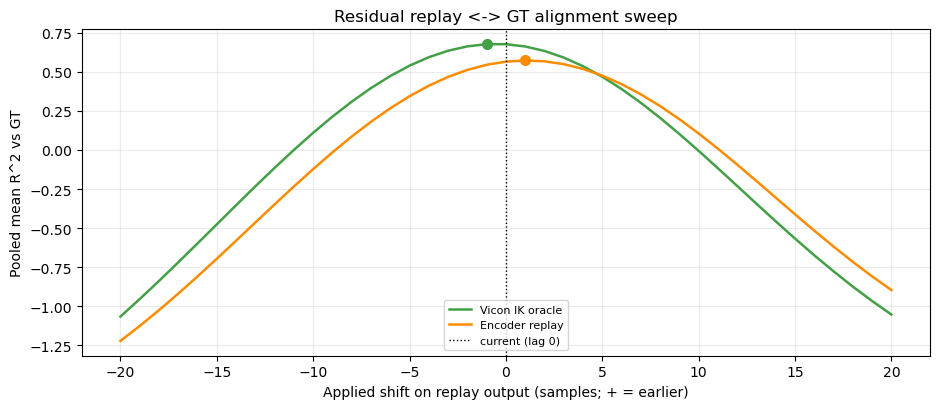

In [13]:
SHIFT_SEARCH_SAMPLES = 20  # +/-20 samples = +/-0.2 s at 100 Hz
_lags = np.arange(-SHIFT_SEARCH_SAMPLES, SHIFT_SEARCH_SAMPLES + 1)
_SHIFT_SERIES = (
    ('Vicon IK oracle', 'vicon_ik_model_out_nmpkg', '#43a047'),
    ('Encoder replay', 'encoder_replay_model_out_nmpkg', '#fb8c00'),
)

_per_trial_rows = []
_agg_r2 = {label: np.zeros_like(_lags, dtype=np.float64) for label, _, _ in _SHIFT_SERIES}
_agg_n = {label: 0 for label, _, _ in _SHIFT_SERIES}

for stem, wave in sorted(REPLAY_DATA.items()):
    m = analysis_trim_mask(wave['t'])
    gt = wave['gt_nmpkg']
    fs = float(wave.get('fs_hz', 100.0))
    for label, col, _color in _SHIFT_SERIES:
        if label == 'Encoder replay' and bool(wave.get('encoder_replay_excluded', False)):
            continue
        pred = wave[col]
        res = [rmse_r2(gt[m], _shift_samples_1d(pred, int(L))[m]) for L in _lags]
        rmse_by_lag = np.array([r[0] for r in res], dtype=np.float64)
        r2_by_lag = np.array([r[1] for r in res], dtype=np.float64)
        i0 = int(np.where(_lags == 0)[0][0])
        ibest = int(np.nanargmin(rmse_by_lag))
        _per_trial_rows.append({
            'trial': stem,
            'series': label,
            'best_lag': int(_lags[ibest]),
            'best_lag_ms': float(_lags[ibest] / fs * 1000.0),
            'r2_now': float(r2_by_lag[i0]),
            'r2_shift': float(r2_by_lag[ibest]),
            'd_r2': float(r2_by_lag[ibest] - r2_by_lag[i0]),
            'rmse_now': float(rmse_by_lag[i0]),
            'rmse_shift': float(rmse_by_lag[ibest]),
            'd_rmse': float(rmse_by_lag[ibest] - rmse_by_lag[i0]),
        })
        _agg_r2[label] += r2_by_lag
        _agg_n[label] += 1

shift_df = pd.DataFrame(_per_trial_rows)
display(shift_df.round(4))

print('Per-trial best shift (minimize RMSE vs GT):')
for label, _, _ in _SHIFT_SERIES:
    sub = shift_df[shift_df['series'] == label]
    if sub.empty:
        continue
    print(
        f"  {label:16s}: mean R2 {sub['r2_now'].mean():.4f} -> {sub['r2_shift'].mean():.4f} "
        f"(+{sub['d_r2'].mean():.4f}) | best lag median {sub['best_lag'].median():+.0f} samples "
        f"[{sub['best_lag'].min():+d}, {sub['best_lag'].max():+d}]"
    )

fig, ax = plt.subplots(figsize=(9.5, 4.2))
print('\nBest single GLOBAL shift (pooled mean R2 across trials):')
for label, _, color in _SHIFT_SERIES:
    n = max(_agg_n[label], 1)
    mean_r2 = _agg_r2[label] / n
    ib = int(np.nanargmax(mean_r2))
    i0 = int(np.where(_lags == 0)[0][0])
    ax.plot(_lags, mean_r2, color=color, lw=1.8, label=label)
    ax.plot(_lags[ib], mean_r2[ib], 'o', color=color, ms=7)
    print(
        f"  {label:16s}: lag 0 R2={mean_r2[i0]:.4f} -> best lag {_lags[ib]:+d} "
        f"samples ({_lags[ib] / 100.0 * 1000:.0f} ms) R2={mean_r2[ib]:.4f} (+{mean_r2[ib] - mean_r2[i0]:.4f})"
    )
ax.axvline(0, color='black', ls=':', lw=1.0, label='current (lag 0)')
ax.set_xlabel('Applied shift on replay output (samples; + = earlier)')
ax.set_ylabel('Pooled mean R^2 vs GT')
ax.set_title('Residual replay <-> GT alignment sweep')
ax.legend(loc='lower center', fontsize=8)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 4. Paper-ready outputs

Exports tables (CSV + LaTeX) and figures (PDF + PNG @ 300 dpi) for **encoder replay** and **Vicon IK oracle** vs GT to `analysis/paper_outputs/knee_exo/`.


Paper outputs → /home/metamobility3/Jinwoo/os_kinetics/analysis/paper_outputs/knee_exo
  Sync: gpio_falling_edge | trim: 10s start + 10s end
  Vicon trials: 13 | Encoder trials: 13 (excluded broken-encoder trials)


,joint,n_trials_vicon,n_trials_encoder,rmse_encoder_mean_std,r2_encoder_mean_std,rmse_vicon_mean_std,r2_vicon_mean_std
0,Knee R,13,13,0.192 ± 0.040,0.566 ± 0.232,0.159 ± 0.036,0.678 ± 0.237


,subject,condition,task,speed_mps,rmse_encoder_replay_nmpkg,r2_encoder_replay_nmpkg,rmse_vicon_oracle_nmpkg,r2_vicon_oracle_nmpkg,encoder_replay_excluded,encoder_correction_note,offset_s
0,AB01_Jinwoo,RA_0p8mps,RA,0.8,0.1344,0.8133,0.1133,0.8673,False,no LPF; logged raw vel; GT ID xcorr shift +3 s...,-0.0510
1,AB01_Jinwoo,RD_0p8mps,RD,0.8,0.2287,0.6491,0.1534,0.8420,False,no LPF; logged raw vel; GT ID xcorr shift +2 s...,-0.1201
2,AB03_Ilseung,RA_0p8mps,RA,0.8,0.1778,0.7282,0.1712,0.7481,False,no LPF; logged raw vel; GT ID xcorr shift +3 s...,-0.1801
3,AB03_Ilseung,RD_0p8mps,RD,0.8,0.2593,0.3477,0.1601,0.7512,False,no LPF; logged raw vel; GT ID xcorr shift +2 s...,-0.1961
4,AB04_Changseob,RA_0p8mps,RA,0.8,0.1249,0.8147,0.1151,0.8428,False,no LPF; logged raw vel; GT ID xcorr shift +3 s...,-0.2131
5,AB04_Changseob,RD_0p8mps,RD,0.8,0.1831,0.7176,0.1617,0.7799,False,no LPF; logged raw vel; GT ID xcorr shift +2 s...,-0.2300
6,AB05_Maria,RA_0p8mps,RA,0.8,0.2038,0.7323,0.1564,0.8424,False,no LPF; logged raw vel; GT ID xcorr shift +3 s...,-0.1791
7,AB06_Jimin,RA_0p8mps,RA,0.8,0.2066,0.5076,0.1468,0.7513,False,no LPF; logged raw vel; GT ID xcorr shift +3 s...,-0.2370
8,AB06_Jimin,RD_0p8mps,RD,0.8,0.1694,0.7072,0.1093,0.8782,False,no LPF; logged raw vel; GT ID xcorr shift +3 s...,-0.2301
9,AB07_Amy,RA_0p8mps,RA,0.8,0.1590,0.3418,0.1596,0.3367,False,no LPF; logged raw vel; GT ID xcorr shift +4 s...,-0.2380


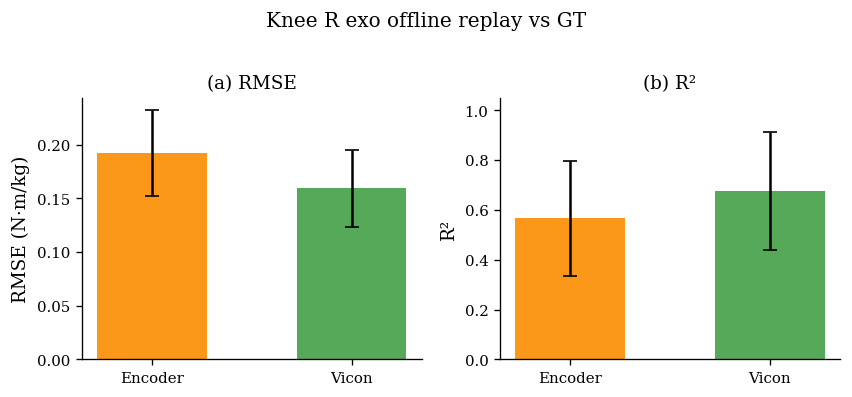

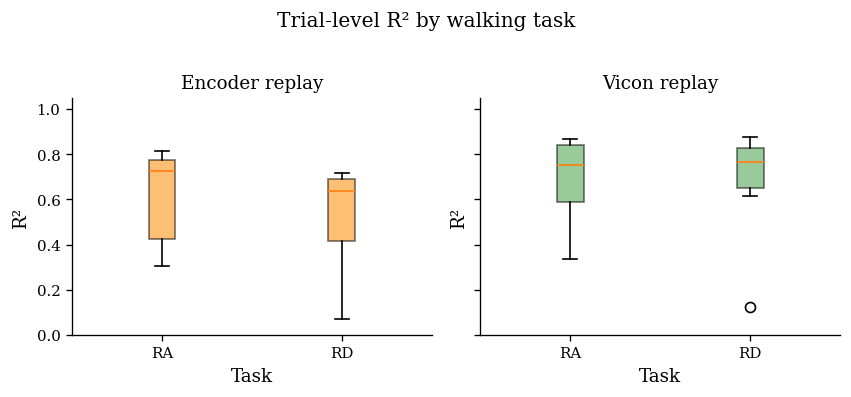

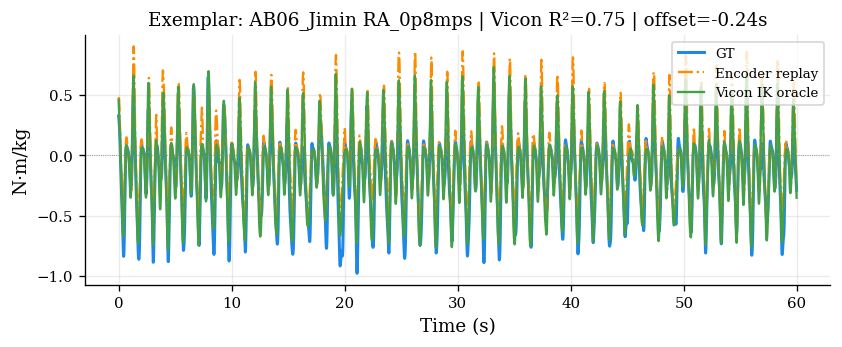


Saved files:
  fig1_summary.pdf
  fig1_summary.png
  fig2_r2_by_task.pdf
  fig2_r2_by_task.png
  fig3_exemplar_timeseries.pdf
  fig3_exemplar_timeseries.png
  table1_summary.csv
  table1_summary.tex
  table2_per_trial.csv
  table2_per_trial.tex
  table3_overall.csv
  table3_overall.tex


In [14]:
if 'replay_metrics_df' not in dir() or 'REPLAY_DATA' not in dir():
    raise RuntimeError('Run §3 offline replay first.')

# Paper uses the same EXCLUDE_SUBJECTS / EXCLUDE_TRIALS from config.
OUT_DIR = PROJECT_ROOT / 'analysis' / 'paper_outputs' / PAPER_SUBDIR
OUT_DIR.mkdir(parents=True, exist_ok=True)

PAPER_RC = {
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'legend.fontsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
}
PALETTE = {'GT': '#1e88e5', 'Encoder': '#fb8c00', 'Vicon': '#43a047'}
TASK_ORDER = ['LG', 'RA', 'RD']


def _paper_exclude(trial_key: str) -> bool:
    return is_excluded_trial_key(trial_key)


def _mean_std(series, decimals=3):
    x = np.asarray(series, dtype=np.float64)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return '—'
    return f'{np.mean(x):.{decimals}f} ± {np.std(x, ddof=1):.{decimals}f}'


def _save_table(df, stem, caption=''):
    csv_path = OUT_DIR / f'{stem}.csv'
    tex_path = OUT_DIR / f'{stem}.tex'
    df.to_csv(csv_path, index=False)
    tex = df.to_latex(index=False, escape=True, caption=caption, label=f'tab:{stem}')
    tex_path.write_text(tex)
    return csv_path, tex_path


replay_paper = replay_metrics_df[~replay_metrics_df['trial_key'].map(_paper_exclude)].copy()
enc_paper = replay_paper[~replay_paper['encoder_replay_excluded']].copy()

table_summary = pd.DataFrame([{
    'joint': JOINT_LABEL,
    'n_trials_vicon': len(replay_paper),
    'n_trials_encoder': len(enc_paper),
    'rmse_encoder_mean_std': _mean_std(enc_paper['rmse_encoder_replay_nmpkg']),
    'r2_encoder_mean_std': _mean_std(enc_paper['r2_encoder_replay_nmpkg']),
    'rmse_vicon_mean_std': _mean_std(replay_paper['rmse_vicon_oracle_nmpkg']),
    'r2_vicon_mean_std': _mean_std(replay_paper['r2_vicon_oracle_nmpkg']),
}])

table_per_trial = replay_paper[[
    'subject', 'condition', 'task', 'speed_mps',
    'rmse_encoder_replay_nmpkg', 'r2_encoder_replay_nmpkg',
    'rmse_vicon_oracle_nmpkg', 'r2_vicon_oracle_nmpkg',
    'encoder_replay_excluded', 'encoder_correction_note', 'offset_s',
]].sort_values(['subject', 'task']).round(4)

table_overall = pd.DataFrame([
    {
        'replay_method': 'Encoder replay',
        'unit': 'N·m/kg / R²',
        'rmse_mean_std': _mean_std(enc_paper['rmse_encoder_replay_nmpkg']),
        'r2_mean_std': _mean_std(enc_paper['r2_encoder_replay_nmpkg']),
        'n_trials': len(enc_paper),
    },
    {
        'replay_method': 'Vicon IK oracle',
        'unit': 'N·m/kg / R²',
        'rmse_mean_std': _mean_std(replay_paper['rmse_vicon_oracle_nmpkg']),
        'r2_mean_std': _mean_std(replay_paper['r2_vicon_oracle_nmpkg']),
        'n_trials': len(replay_paper),
    },
])

for stem, df, cap in [
    ('table1_summary', table_summary,
     f'{JOINT_LABEL} exo offline replay vs GT (GPIO sync, {TRIM_START_SEC:.0f}s start + {TRIM_END_SEC:.0f}s end trim).'),
    ('table2_per_trial', table_per_trial, 'Per-trial encoder replay and Vicon IK oracle metrics.'),
    ('table3_overall', table_overall, 'Overall summary across paper trials.'),
]:
    _save_table(df, stem, caption=cap)

print(f'Paper outputs → {OUT_DIR}')
print(f'  Sync: gpio_falling_edge | trim: {TRIM_START_SEC:.0f}s start + {TRIM_END_SEC:.0f}s end')
print(f'  Vicon trials: {len(replay_paper)} | Encoder trials: {len(enc_paper)} (excluded broken-encoder trials)')
display(table_summary)
display(table_per_trial.head(12))

task_order = [t for t in TASK_ORDER if t in replay_paper['task'].unique()]
methods = [('Encoder', enc_paper, 'rmse_encoder_replay_nmpkg', 'r2_encoder_replay_nmpkg'),
           ('Vicon', replay_paper, 'rmse_vicon_oracle_nmpkg', 'r2_vicon_oracle_nmpkg')]

with plt.rc_context(PAPER_RC):
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.2))
    x = np.arange(len(methods))
    rmse_means = [df[rmse_col].mean() for _, df, rmse_col, _ in methods]
    rmse_stds = [df[rmse_col].std(ddof=1) for _, df, rmse_col, _ in methods]
    r2_means = [df[r2_col].mean() for _, df, _, r2_col in methods]
    r2_stds = [df[r2_col].std(ddof=1) for _, df, _, r2_col in methods]
    labels = [name for name, *_ in methods]

    axes[0].bar(x, rmse_means, yerr=rmse_stds, color=[PALETTE['Encoder'], PALETTE['Vicon']],
                capsize=4, alpha=0.9, width=0.55)
    axes[0].set_xticks(x); axes[0].set_xticklabels(labels)
    axes[0].set_ylabel('RMSE (N·m/kg)'); axes[0].set_title('(a) RMSE')

    axes[1].bar(x, r2_means, yerr=r2_stds, color=[PALETTE['Encoder'], PALETTE['Vicon']],
                capsize=4, alpha=0.9, width=0.55)
    axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
    axes[1].set_ylabel('R²'); axes[1].set_ylim(0, 1.05); axes[1].set_title('(b) R²')

    fig.suptitle(f'{JOINT_LABEL} exo offline replay vs GT', y=1.02, fontsize=12)
    fig.tight_layout()
    for ext in ('pdf', 'png'):
        fig.savefig(OUT_DIR / f'fig1_summary.{ext}')
    plt.show()

    if len(task_order) >= 2:
        fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.2), sharey=True)
        for ax, (label, df, _, r2_col), color in zip(
            axes,
            methods,
            [PALETTE['Encoder'], PALETTE['Vicon']],
        ):
            groups = [df.loc[df['task'] == t, r2_col].to_numpy() for t in task_order]
            bp = ax.boxplot(groups, tick_labels=task_order, patch_artist=True)
            for box in bp['boxes']:
                box.set(facecolor=color, alpha=0.55)
            ax.set_ylabel('R²'); ax.set_xlabel('Task')
            ax.set_title(f'{label} replay')
            ax.set_ylim(0, 1.05)
        fig.suptitle('Trial-level R² by walking task', y=1.02, fontsize=12)
        fig.tight_layout()
        for ext in ('pdf', 'png'):
            fig.savefig(OUT_DIR / f'fig2_r2_by_task.{ext}')
        plt.show()

    ex_idx = (
        replay_paper['r2_vicon_oracle_nmpkg'] - replay_paper['r2_vicon_oracle_nmpkg'].median()
    ).abs().argsort().iloc[0]
    ex_stem = replay_paper.iloc[ex_idx]['trial']
    ex_row = replay_paper.iloc[ex_idx]
    wave = REPLAY_DATA[ex_stem]
    m = analysis_trim_mask(wave['t'])
    t = wave['t'][m] - np.nanmin(wave['t'][m])
    gt = wave['gt_nmpkg'][m]
    vicon = wave['vicon_ik_model_out_nmpkg'][m]
    enc = wave['encoder_replay_model_out_nmpkg'][m]
    enc_excluded = bool(wave.get('encoder_replay_excluded', False))

    fig, ax = plt.subplots(figsize=(7.2, 3.0))
    ax.plot(t, gt, color=PALETTE['GT'], lw=1.8, label='GT')
    if enc_excluded:
        ax.plot([], [], color=PALETTE['Encoder'], ls='-.', label='Encoder (excluded)')
    else:
        ax.plot(t, enc, color=PALETTE['Encoder'], lw=1.4, ls='-.', label='Encoder replay')
    ax.plot(t, vicon, color=PALETTE['Vicon'], lw=1.4, label='Vicon IK oracle')
    ax.axhline(0, color='gray', lw=0.5, ls=':')
    ax.set_xlabel('Time (s)'); ax.set_ylabel('N·m/kg')
    ax.set_title(
        f'Exemplar: {ex_row["subject"]} {ex_row["condition"]} | '
        f'Vicon R²={ex_row["r2_vicon_oracle_nmpkg"]:.2f} | offset={ex_row["offset_s"]:+.2f}s'
    )
    ax.legend(fontsize=8); ax.grid(alpha=0.25)
    fig.tight_layout()
    for ext in ('pdf', 'png'):
        fig.savefig(OUT_DIR / f'fig3_exemplar_timeseries.{ext}')
    plt.show()

print('\nSaved files:')
for p in sorted(OUT_DIR.glob('*')):
    print(f'  {p.name}')
